In [1]:
import pandas as pd

print("Pandas version:", pd.__version__)

df = pd.read_csv("Amazon Sale Report.csv")

print("Dataset Loaded Successfully")

print(df.shape)

Pandas version: 2.3.3
Dataset Loaded Successfully
(128976, 21)


In [2]:
print(df.head())
print(df.columns)
print(df.info())

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel ship-service-level  Category Size Courier Status  \
0   Merchant     Amazon.in           Standard   T-shirt    S     On the Way   
1   Merchant     Amazon.in           Standard     Shirt  3XL        Shipped   
2     Amazon     Amazon.in          Expedited     Shirt   XL        Shipped   
3   Merchant     Amazon.in           Standard   Blazzer    L     On the Way   
4     Amazon     Amazon.in          Expedited  Trousers  3XL        Shipped   

   ...  currency  Amount    ship-city   ship-state ship-postal-code  \
0  ...       IN

In [3]:
import pandas as pd

df = pd.read_csv("Amazon Sale Report.csv")

print(df.head())

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel ship-service-level  Category Size Courier Status  \
0   Merchant     Amazon.in           Standard   T-shirt    S     On the Way   
1   Merchant     Amazon.in           Standard     Shirt  3XL        Shipped   
2     Amazon     Amazon.in          Expedited     Shirt   XL        Shipped   
3   Merchant     Amazon.in           Standard   Blazzer    L     On the Way   
4     Amazon     Amazon.in          Expedited  Trousers  3XL        Shipped   

   ...  currency  Amount    ship-city   ship-state ship-postal-code  \
0  ...       IN

In [4]:
print(df.columns)

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')


In [5]:
print(df.shape)

(128976, 21)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [7]:
print(df.isnull().sum())


index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64


In [8]:
print(df.isnull().sum())

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64


In [9]:

# Remove useless columns

df.drop(columns=["New", "PendingS"], inplace=True)

# Remove rows where Amount is missing

df.dropna(subset=["Amount"], inplace=True)

print("New Shape:", df.shape)

New Shape: (121176, 19)


In [10]:
total_sales = df["Amount"].sum()

print("Total Sales =", total_sales)

Total Sales = 78590170.25


In [11]:
total_orders = len(df)

print("Total Orders =", total_orders)

Total Orders = 121176


In [12]:
avg_order = df["Amount"].mean()

print("Average Order Value =", avg_order)

Average Order Value = 648.5621760909751


In [13]:
category_sales = (
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
T-shirt     39206756.65
Shirt       21297770.08
Blazzer     11215104.12
Trousers     5346286.30
Perfume       789419.66
Wallet        458408.18
Socks         150757.50
Shoes         124752.76
Watch            915.00
Name: Amount, dtype: float64


In [14]:

#TOP 10 STATES BY SALES
state_sales = (
    df.groupby("ship-state")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(state_sales)

ship-state
MAHARASHTRA       13340333.05
KARNATAKA         10480694.22
TELANGANA          6915018.08
UTTAR PRADESH      6823947.08
TAMIL NADU         6519182.30
DELHI              4232738.97
KERALA             3823559.58
WEST BENGAL        3507212.82
ANDHRA PRADESH     3217859.86
HARYANA            2880355.99
Name: Amount, dtype: float64


In [15]:
#TOP 10 CITIES
city_sales = (
    df.groupby("ship-city")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(city_sales)

ship-city
BENGALURU    6845390.65
HYDERABAD    4946394.25
MUMBAI       3701843.04
NEW DELHI    3612512.78
CHENNAI      3103415.74
PUNE         2342011.18
KOLKATA      1413603.87
GURUGRAM     1220562.74
THANE        1004503.29
LUCKNOW       938076.34
Name: Amount, dtype: float64


In [16]:
fulfilment_sales = (
    df.groupby("Fulfilment")["Amount"]
    .sum()
)

print(fulfilment_sales)

Fulfilment
Amazon      54327540.00
Merchant    24262630.25
Name: Amount, dtype: float64


In [18]:
#MONTHLY SALES TREND
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

monthly_sales = (
    df.groupby("Month")["Amount"]
    .sum()
)

print(monthly_sales)

Month
3      101683.85
4    28836200.27
5    26226476.75
6    23425809.38
Name: Amount, dtype: float64


In [19]:
#visualization
import matplotlib.pyplot as plt

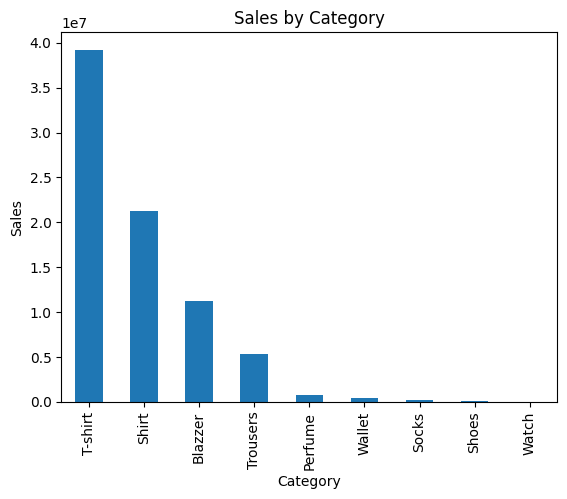

In [20]:
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

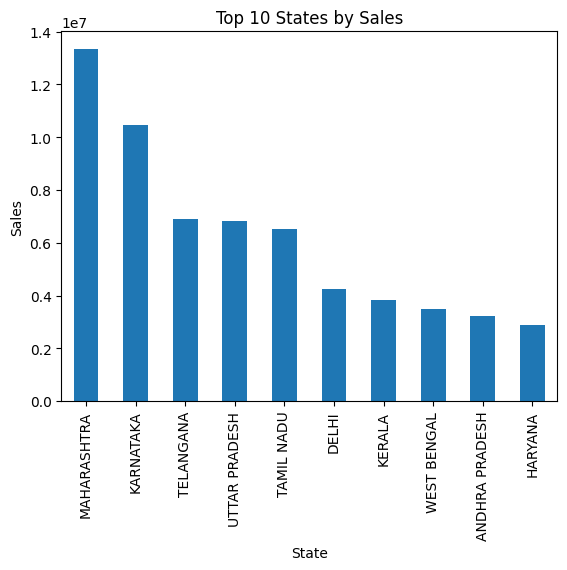

In [21]:
state_sales.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

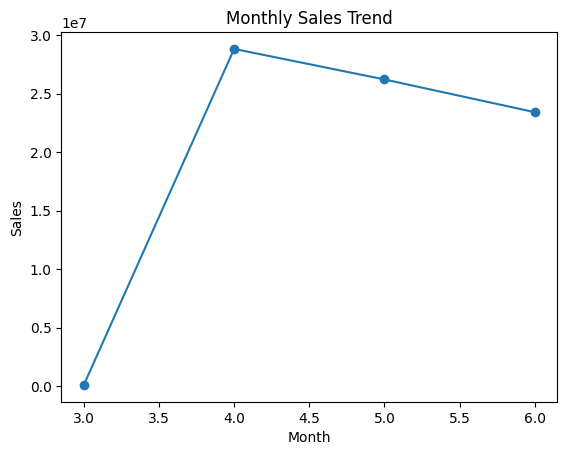

In [22]:
monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [23]:
df.to_csv("cleaned_amazon_sales.csv", index=False)